## Bethe-Bloch Simulation

In [1]:
import numpy as np
import scipy.constants as con

def beta(T: float, E_0: float):
    """
    :T: Kinetische Energie des Teilchens in eV
    :E_0: Ruheenergie des Teilchens in eV
    """
    gamma = (T/E_0)+1
    return np.sqrt(1-1/gamma**2)

class Material:
    def __init__(self, Z, A, I, n):
        """
        :Z: Ladungszahl
        :A: Massenzahl
        :I: mittlere Ionisationsenergy (in J)
        :n: Dichte in g/cm³
        """
        self.I = I
        self.n_e = Z*n*1e3/A/con.u

Au = Material(79, 197, 790*con.e, 19.32)
Si = Material(14, 28, 173*con.e, 2.33)

def Bethe(target: Material, E:float, z=2, E0=3728e6):
    """
    :target: Zielmaterial
    :E: Kinetische Energie des Teilchens in eV
    :z: Ladungszahl des Teilchens
    :E0: Ruheenergie des Teilchens in eV
    """
    n = target.n_e
    I = target.I
    B2 = beta(E, E0)**2
    a = (4*np.pi*n*z**2)/(con.m_e*con.c**2*B2)
    b =(con.e**2/(4*np.pi*con.epsilon_0))**2
    c = np.log((2*con.m_e*con.c**2*B2)/(I*(1-B2))) - B2
    return -a * b * c

def Reichweite(target: Material, E: float, dx=1e-6, Elim=1):
    """
    :target: Materialeigenschaften des Zielmaterials
    :E: Kinetische Energie des Teilchens in eV
    :dx: Schrittweite in m
    """
    l = 0
    while E > Elim: # in eV
        lost = Bethe(target, E) / con.e * dx # Energieverlust in eV
        E -= abs(lost)
        l += dx
    return l

In [2]:
E = np.logspace(4, 8, endpoint=True)

vBethe = np.vectorize(Bethe)
vReich = np.vectorize(Reichweite)

dEdx = vBethe(Si, E)
rw = vReich(Si, E, dx=1e-6)

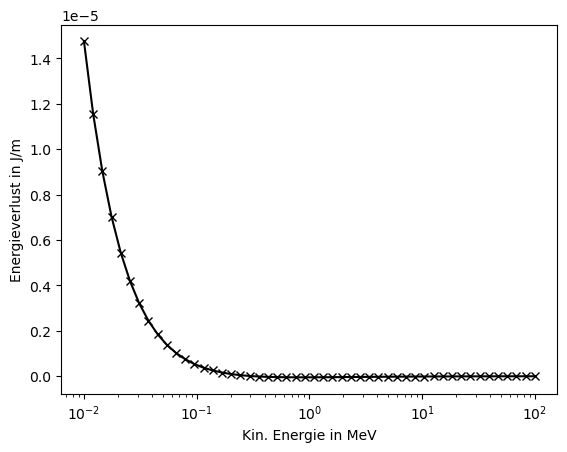

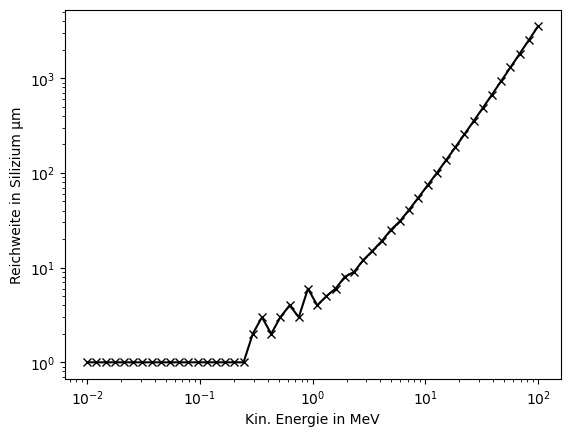

In [3]:
import matplotlib.pyplot as plt

plt.plot(E/1e6, dEdx, 'x-k')
plt.xscale('log')
plt.ylabel('Energieverlust in J/m')
plt.xlabel('Kin. Energie in MeV')

fig, ax = plt.subplots()
ax.plot(E/1e6, rw/1e-6, 'x-k')


ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Kin. Energie in MeV')
ax.set_ylabel('Reichweite in Silizium µm')


plt.show()

## Linearitätsprüfung

In [4]:
import pandas as pd



## $\alpha$-Spektrum fits

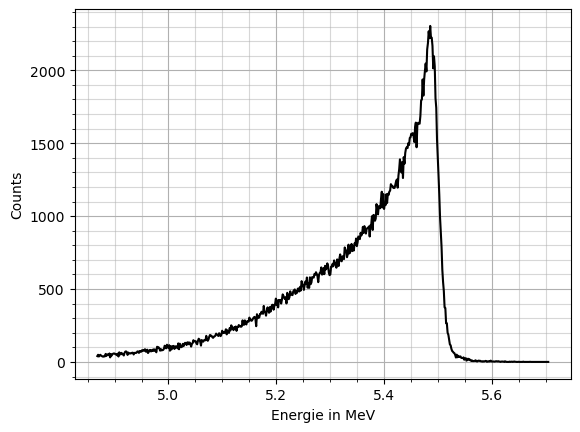

In [5]:
from scipy.optimize import curve_fit

def gaussian(x, mu, sig, A, y0):
    return A*np.exp(-(x-mu)**2/(2*sig**2))+y0

skiprows = 3499#bis 350 eh keine Werte und die 99, damit ich einen Verschub um 400 und eine Nullindizierung habe
#spektrum = np.loadtxt('../Messdaten/19012026_Halbleiter/20260120_Langzeitspektrum_naechster_Tag.TKA', skiprows=skiprows)
spektrum = np.loadtxt('../Messdaten/19012026_Halbleiter/21_1h10_Alpha.TKA', skiprows=skiprows)
#neue Energieachse erstellen über Fixpunkt bei dem Hauptpeak und der Energie/Kanal Zuordnung aus der Linearitätsprüfung
max = 3940 - (skiprows +1) # weil beim Detektor mit 1 angefangen wird
Emax = 5.4857 #MeV
m = 0.0014038#1.0/710.0 aus den zwei Peaks

energie = []

for i in range(len(spektrum)):
    energie.append(Emax + m*(i-max))

energie = np.array(energie)

fig, ax = plt.subplots()
ax.plot(energie, spektrum, '-k')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV')
ax.set_ylabel('Counts')

plt.show()

### Fit des Hauptmaximums durch eine Gaußkurve

[5.48587260e+00 1.42727193e-02 2.26388174e+03 7.91118355e+00]


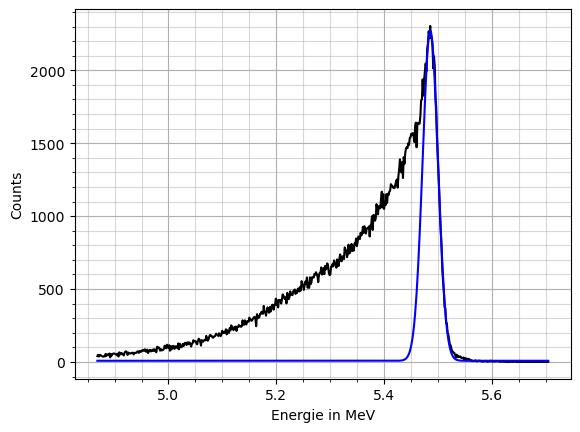

In [6]:
bereich1 = np.where(5.485<energie)

guess = [5.4857, 0.014, 2260, 0]
#guess = [5.4857, 0.014, 41000, 0]
popt1, pcov1 = curve_fit(gaussian, energie[bereich1], spektrum[bereich1], guess)
print(popt1)

fig, ax = plt.subplots()
ax.plot(energie, spektrum, '-k')
ax.plot(energie, gaussian(energie,*popt1), '-b')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV')
ax.set_ylabel('Counts')

plt.show()

Abziehen des ersten Fits und dann Fit des Maximums bei 5.443MeV

[ 5.44085841e+00  2.04258163e-02  1.54913667e+03 -8.42979001e+00]


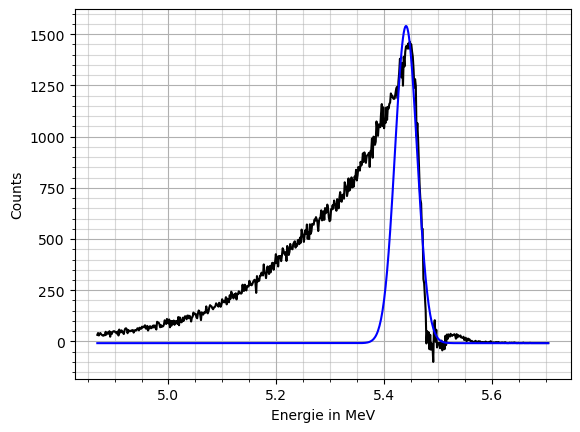

In [7]:
spektrum2 = spektrum - gaussian(energie, *popt1)

bereich2 = np.where(5.42<energie)

guess2 = [5.443, 0.05, 1400, 0]
#guess2 = [5.443, 0.05, 3000, 0]
popt2, pcov2 = curve_fit(gaussian, energie[bereich2], spektrum2[bereich2], guess2)
print(popt2)

fig, ax = plt.subplots()
ax.plot(energie, spektrum2, '-k')
ax.plot(energie, gaussian(energie,*popt2), '-b')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV')
ax.set_ylabel('Counts')

plt.show()

Abziehen des zweiten Fits und dann Fit des dritten Peaks bei 5.388MeV

[ 5.38908862e+00  1.90159188e-02  1.06246871e+03 -5.76335493e+00]


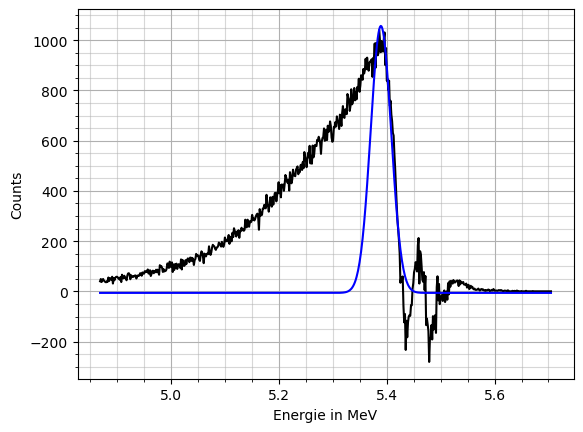

In [8]:
spektrum3 = spektrum2 - gaussian(energie, *popt2)

bereich3 = np.where(5.374<energie)

guess3 = [5.388, 0.014, 1100, 0]
#guess3 = [5.388, 0.014, 2500, 0]
popt3, pcov3 = curve_fit(gaussian, energie[bereich3], spektrum3[bereich3], guess3)
print(popt3)

fig, ax = plt.subplots()
ax.plot(energie, spektrum3, '-k')
ax.plot(energie, gaussian(energie,*popt3), '-b')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV')
ax.set_ylabel('Counts')

plt.show()

zusätzlicher Fit der Peaks rechts bei 5.512MeV und 5.5443 MeV, wobei letzterer angepeilt wird, weil der davor dem Rauschen zum Opfer gefallen ist

[5.50661516e+00 3.20582908e-02 5.09250742e+01 7.24489024e+00]


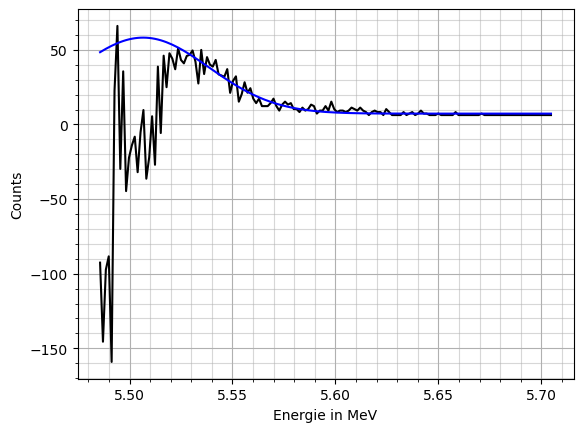

In [9]:
spektrum4 = spektrum3 - gaussian(energie, *popt3)

bereich4 = np.where(5.53<energie)

guess4 = [5.5443, 0.05, 40, 0]
#guess4 = [5.5443, 0.05, 1000, 0]
popt4, pcov4 = curve_fit(gaussian, energie[bereich4], spektrum4[bereich4], guess4)
print(popt4)

fig, ax = plt.subplots()
ax.plot(energie[bereich1], spektrum4[bereich1], '-k')
ax.plot(energie[bereich1], gaussian(energie[bereich1],*popt4), '-b')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV')
ax.set_ylabel('Counts')

plt.show()

Jetzt alles zusammen, um zu schauen wie gut unser Spektrum dadurch modelliert wird

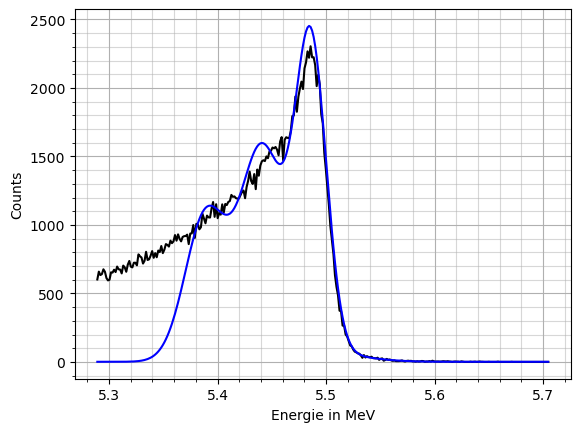

In [10]:

pltbegin = 300

fig, ax = plt.subplots()
ax.plot(energie[pltbegin:], spektrum[pltbegin:], '-k')
ax.plot(energie[pltbegin:], gaussian(energie[pltbegin:],*popt4)+gaussian(energie[pltbegin:],*popt3)+gaussian(energie[pltbegin:],*popt2)+gaussian(energie[pltbegin:],*popt1), '-b')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV')
ax.set_ylabel('Counts')

plt.show()

Alle Gaußkurven in einer Fit-Funktion

[5.48587260e+00 1.42727193e-02 2.26388174e+03 5.44085841e+00
 2.04258163e-02 1.54913667e+03 5.38908862e+00 1.90159188e-02
 1.06246871e+03 5.50661516e+00 3.20582908e-02 5.09250742e+01
 0.00000000e+00]
[5.48916570e+00 1.20084203e-02 1.46498048e+03 5.46265400e+00
 2.38137927e-02 1.02880337e+03 5.40202151e+00 4.64000259e-02
 1.08216834e+03 5.54399031e+00 1.50088922e-02 1.41718735e+01
 1.29858035e+00]


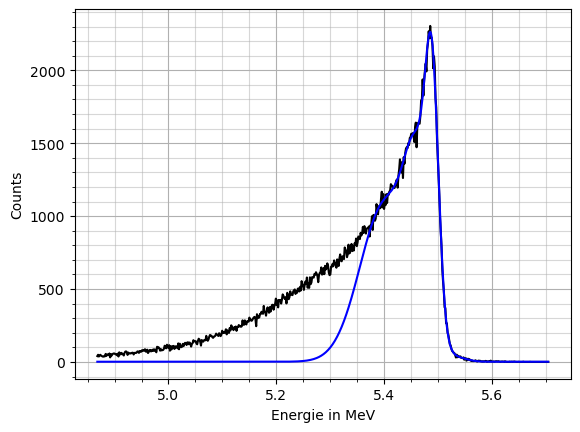

In [11]:
def gaussian4(x, mu1, sig1, A1, mu2, sig2, A2, mu3, sig3, A3, mu4, sig4, A4, y0):
    return A1*np.exp(-(x-mu1)**2/(2*sig1**2))+ A2*np.exp(-(x-mu2)**2/(2*sig2**2)) + A3*np.exp(-(x-mu3)**2/(2*sig3**2))+ A4*np.exp(-(x-mu4)**2/(2*sig4**2))+y0
    #return A1*np.exp(-(x-5.4857)**2/(2*sig1**2))+ A2*np.exp(-(x-5.443)**2/(2*sig2**2)) + A3*np.exp(-(x-5.388 )**2/(2*sig3**2))+ A4*np.exp(-(x-5.528)**2/(2*sig4**2))+y0


guessAll = np.concat([popt1[:3], popt2[:3], popt3[:3], popt4[:3]])
guessAll = np.append(guessAll,0)
print(guessAll)

bereichAll = np.where(5.38<energie)

poptAll, pcovAll = curve_fit(gaussian4, energie[bereichAll], spektrum[bereichAll], guessAll)
print(poptAll)

fig, ax = plt.subplots()
ax.plot(energie, spektrum, '-k')
ax.plot(energie, gaussian4(energie,*poptAll), '-b')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV')
ax.set_ylabel('Counts')

plt.show()


Versuch mit Logarithmieren

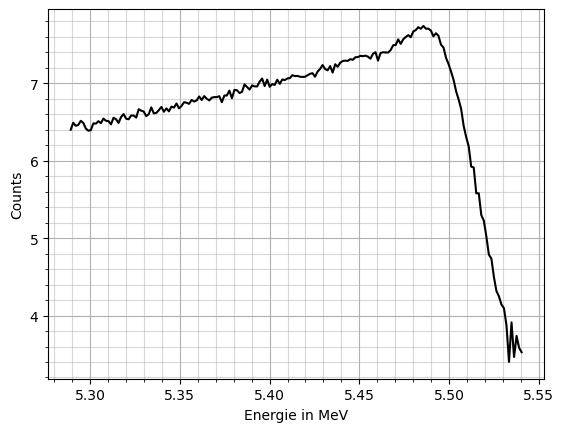

In [12]:
import math as m
spektrumLn = []
for i in spektrum:
    if i == 0:  spektrumLn.append(0)
    else:       spektrumLn.append(m.log(i))

pltbegin, pltende = 300,480

fig, ax = plt.subplots()
ax.plot(energie[pltbegin:pltende], spektrumLn[pltbegin:pltende], '-k')
#ax.plot(energie[pltbegin:], gaussian(energie[pltbegin:],*popt4)+gaussian(energie[pltbegin:],*popt3)+gaussian(energie[pltbegin:],*popt2)+gaussian(energie[pltbegin:],*popt1), '-b')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV')
ax.set_ylabel('Counts')

plt.show()

## Einwöchige Messung

[5.48374456e+00 1.51301531e-02 2.96084435e+05 9.72881897e+02]
[ 5.44337361e+00 -1.71826535e-02  2.19986549e+05 -8.04031167e+02]


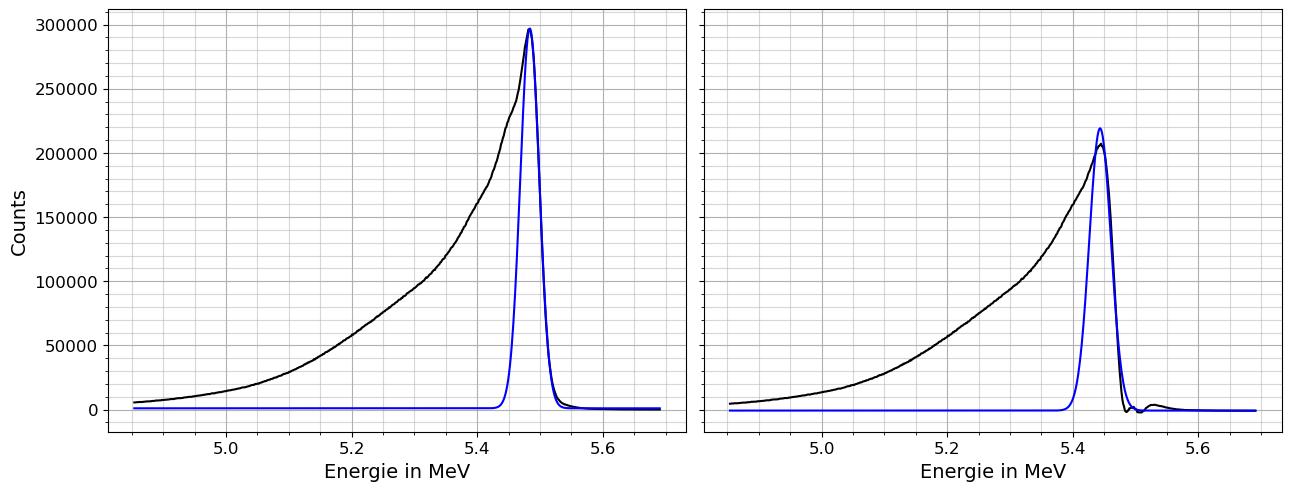

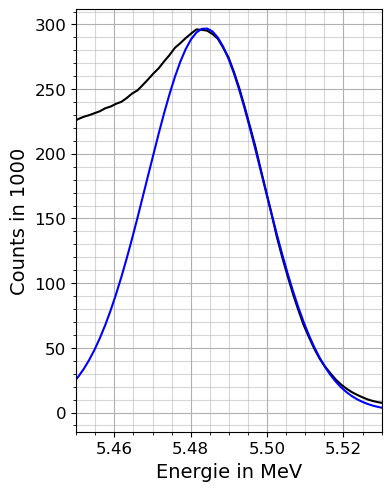

[ 5.39348589e+00  2.15698797e-02  1.66199996e+05 -9.31532560e+02]
[5.52490953e+00 2.41276557e-02 4.26585644e+03 9.02493902e+02]


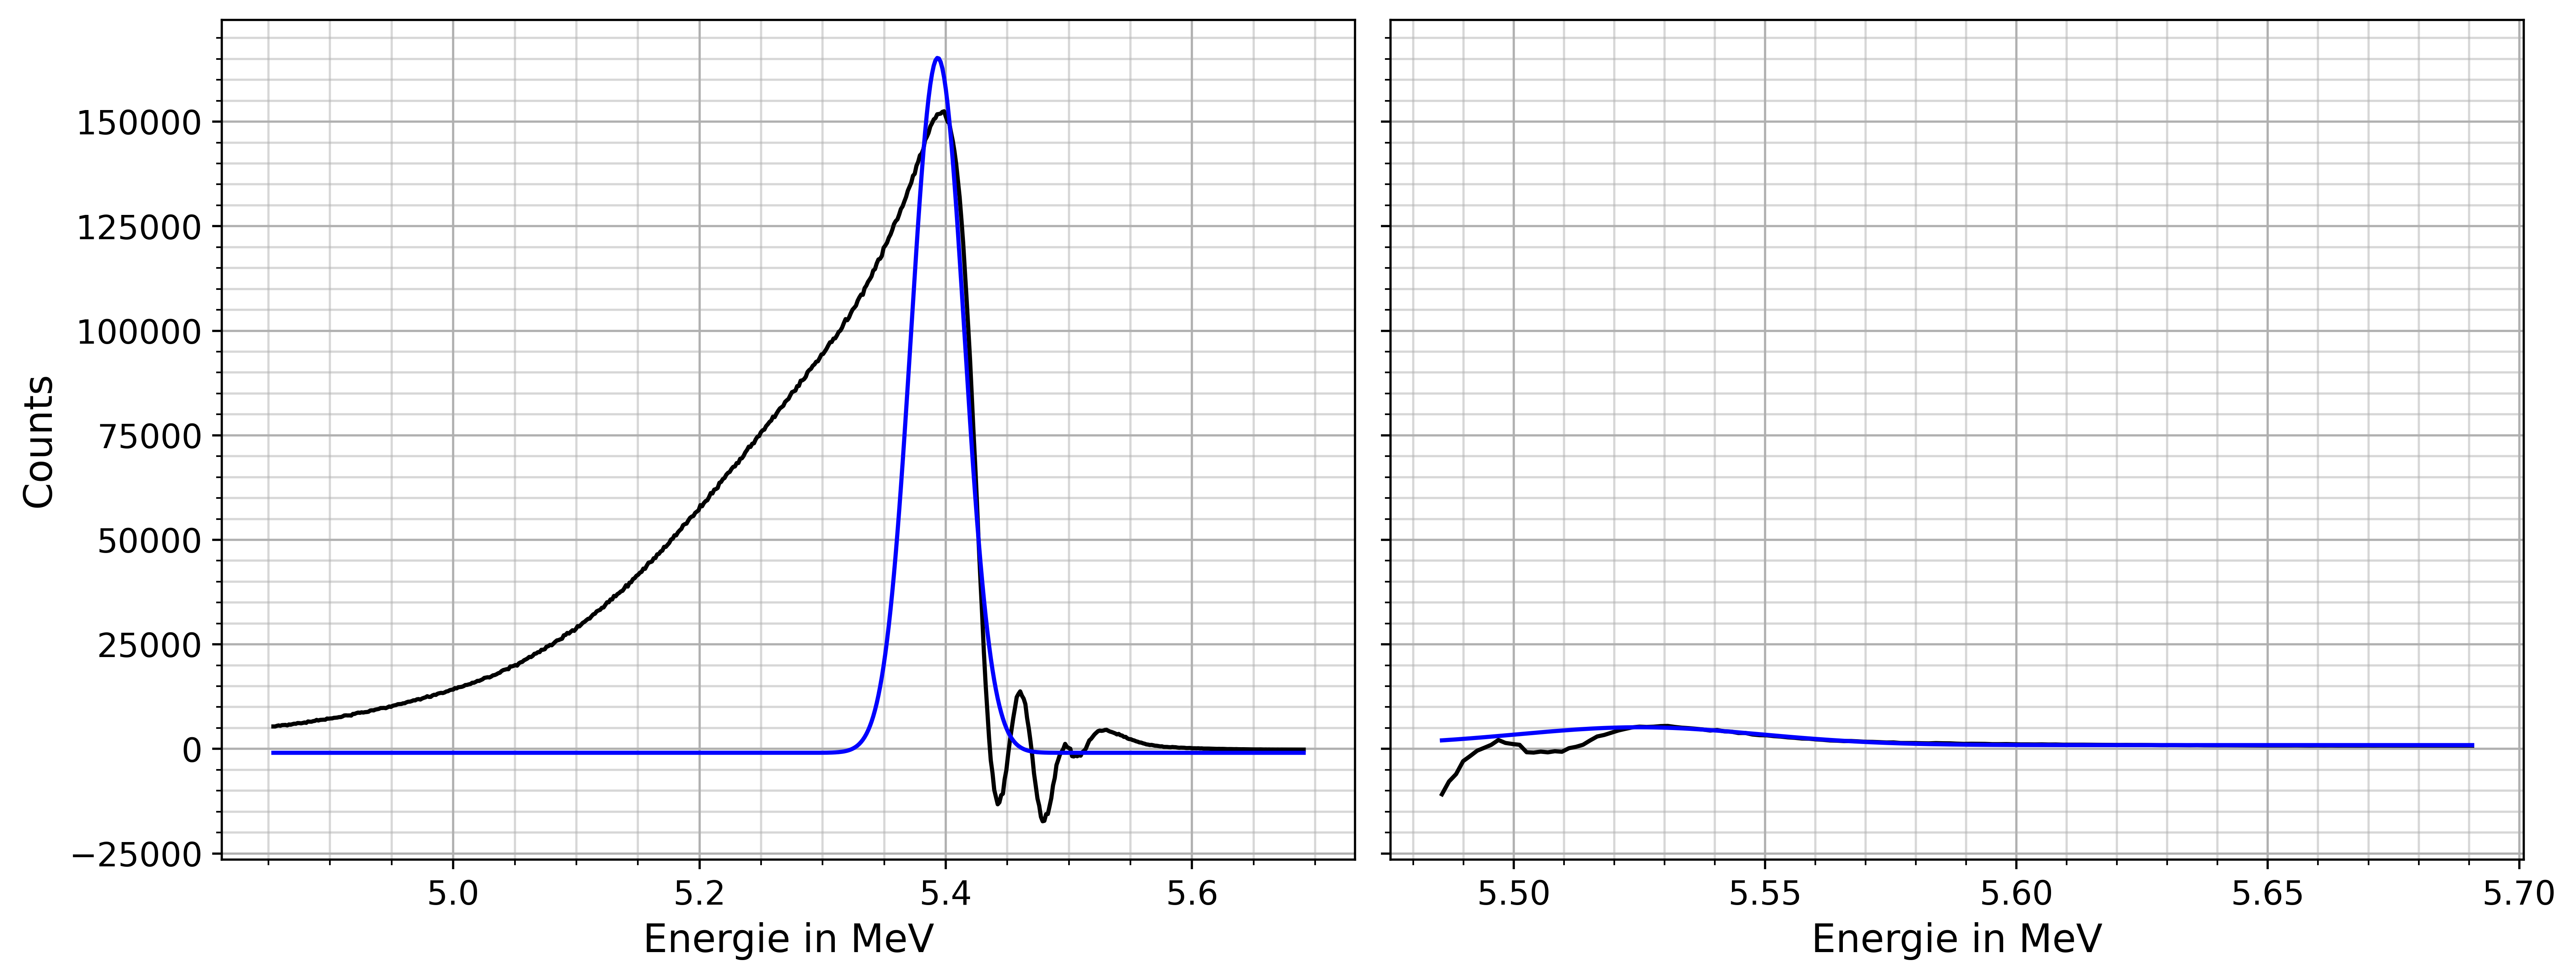

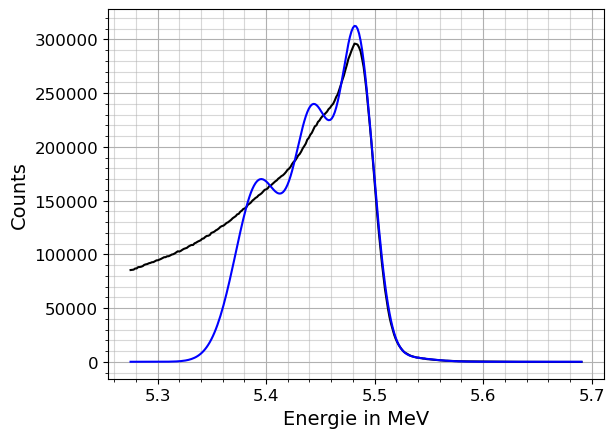

[ 5.48374456e+00  1.51301531e-02  2.96084435e+05  5.44337361e+00
 -1.71826535e-02  2.19986549e+05  5.39348589e+00  2.15698797e-02
  1.66199996e+05  5.52490953e+00  2.41276557e-02  4.26585644e+03
  0.00000000e+00]
[ 5.48786697e+00  1.24770550e-02  1.72524071e+05  5.46238781e+00
 -2.36449508e-02  1.51997818e+05  5.40290117e+00  4.55879520e-02
  1.57632086e+05  5.54865979e+00 -1.53621379e-02  1.46059930e+03
  1.15490381e+02]


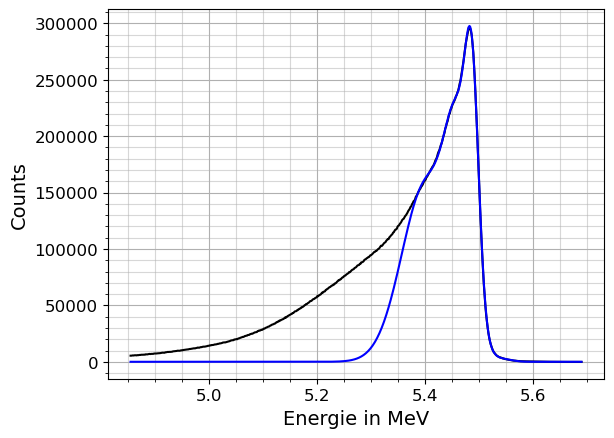

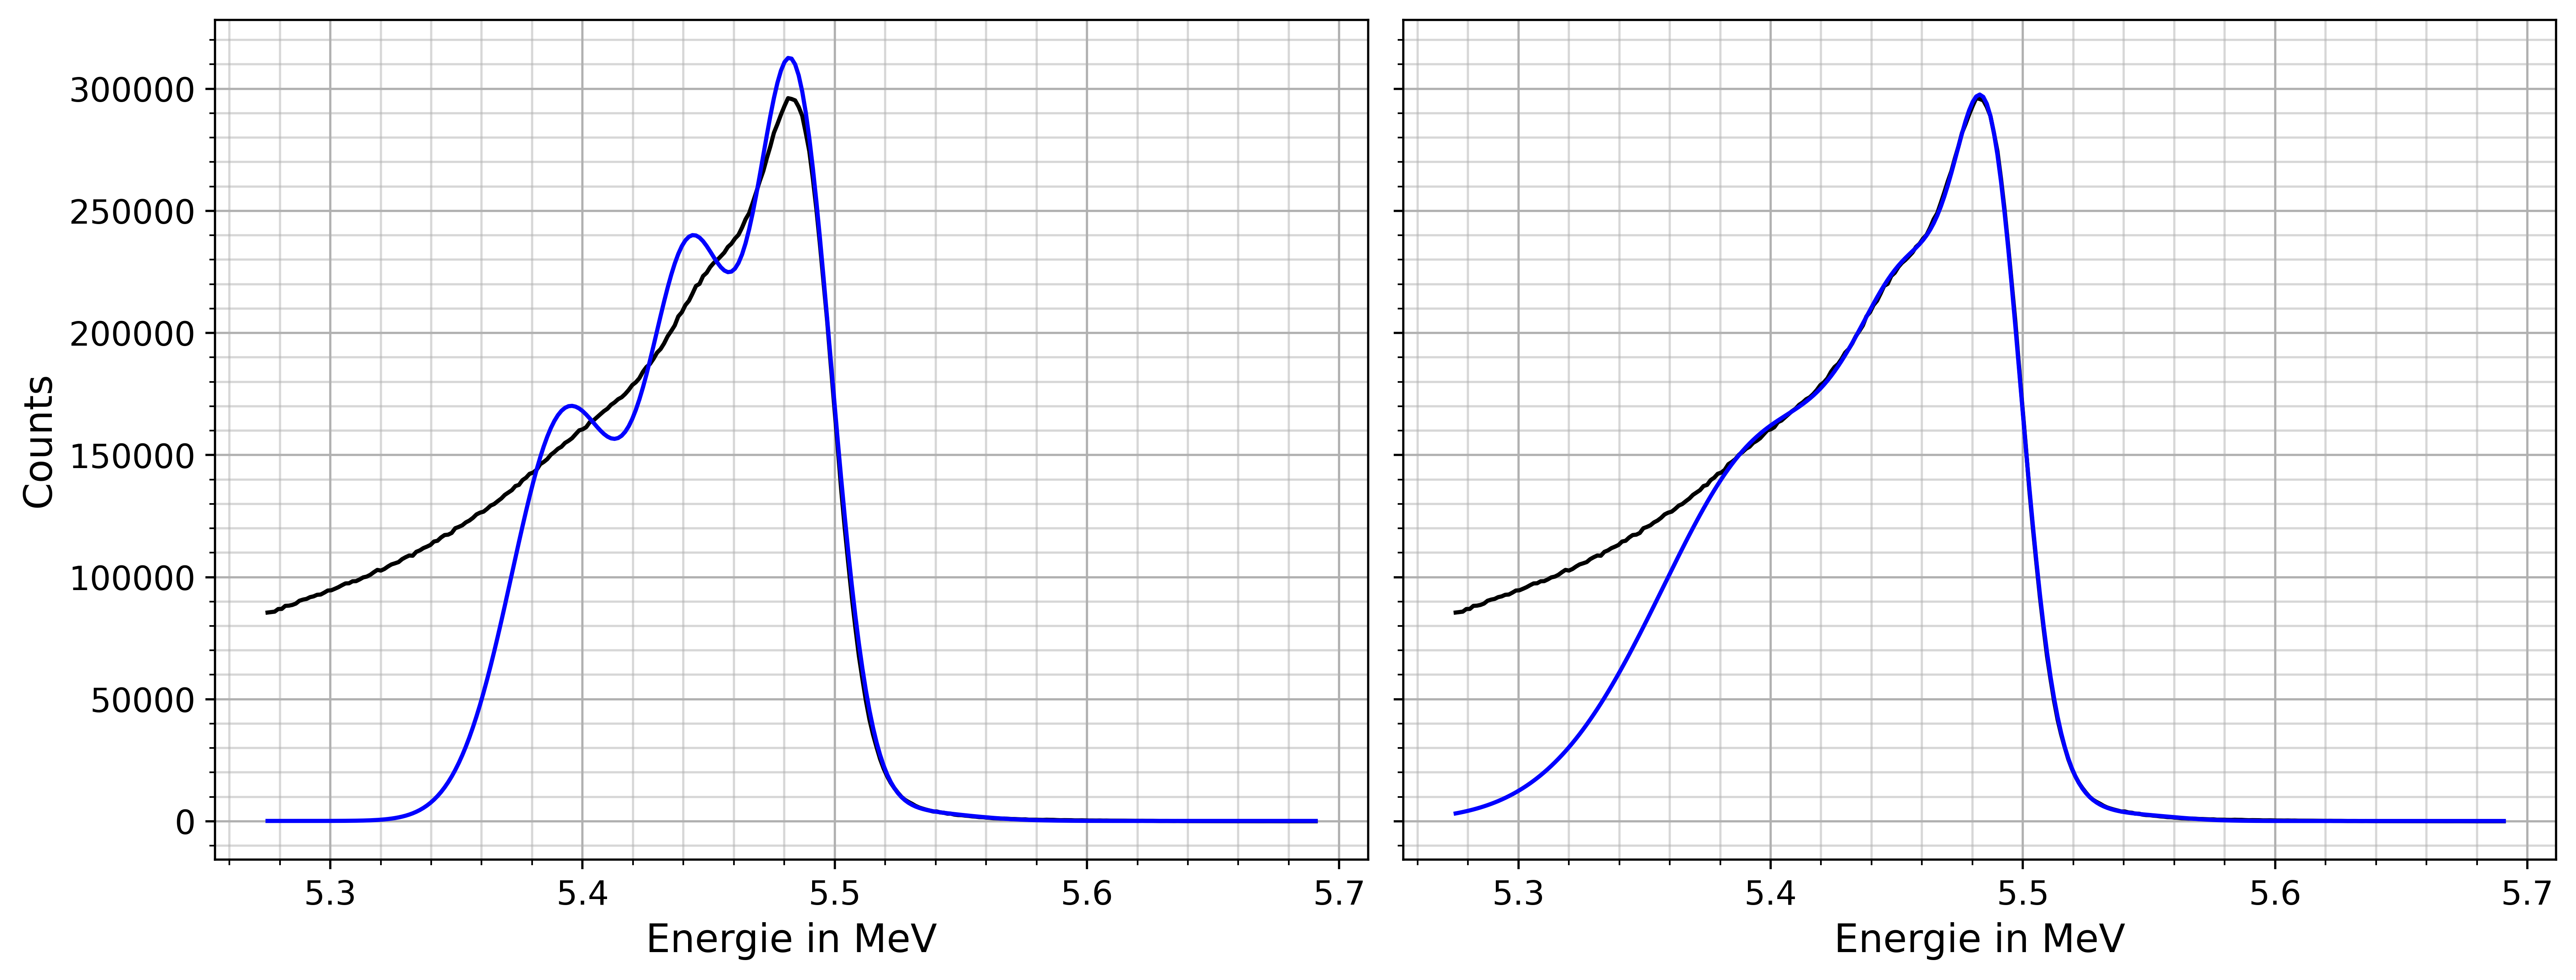

In [17]:
skiprows = 3499#bis 350 eh keine Werte und die 99, damit ich einen Verschub um 400 und eine Nullindizierung habe
#spektrum = np.loadtxt('../Messdaten/19012026_Halbleiter/20260120_Langzeitspektrum_naechster_Tag.TKA', skiprows=skiprows)
#spektrum = np.loadtxt('../Messdaten/19012026_Halbleiter/21_1h10_Alpha.TKA', skiprows=skiprows)
spektrum = np.loadtxt('../Messdaten/19012026_Halbleiter/langzeit_20260126.tka', skiprows=skiprows)
#neue Energieachse erstellen über Fixpunkt bei dem Hauptpeak und der Energie/Kanal Zuordnung aus der Linearitätsprüfung
max = 3950 - (skiprows +1) # weil beim Detektor mit 1 angefangen wird
Emax = 5.4857 #MeV
m = 0.0014038#1.0/710.0 aus den zwei Peaks

energie = []

for i in range(len(spektrum)):
    energie.append(Emax + m*(i-max))

energie = np.array(energie)
# Fit 1
bereich1 = np.where(5.485<energie)

guess = [5.4857, 0.014, 2260, 0]
#guess = [5.4857, 0.014, 41000, 0]
popt1, pcov1 = curve_fit(gaussian, energie[bereich1], spektrum[bereich1], guess)
print(popt1)
# Fit2
spektrum2 = spektrum - gaussian(energie, *popt1)

bereich2 = np.where(5.43<energie)

guess2 = [5.443, 0.05, 1400, 0]
#guess2 = [5.443, 0.05, 3000, 0]
popt2, pcov2 = curve_fit(gaussian, energie[bereich2], spektrum2[bereich2], guess2)
print(popt2)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12.8,4.8), sharey=True, layout='constrained')
ax1.plot(energie, spektrum, '-k')
ax1.plot(energie, gaussian(energie,*popt1), '-b')
ax1.minorticks_on()
ax1.grid(which='major')
ax1.grid(which='minor', alpha=0.5)
ax1.set_xlabel('Energie in MeV', fontsize=14)
ax1.set_ylabel('Counts', fontsize=14)
ax1.tick_params(axis="both", labelsize= 12)
ax2.plot(energie, spektrum2, '-k')
ax2.plot(energie, gaussian(energie,*popt2), '-b')
ax2.minorticks_on()
ax2.grid(which='major')
ax2.grid(which='minor', alpha=0.5)
ax2.set_xlabel('Energie in MeV', fontsize=14)
ax2.tick_params(axis="both", labelsize= 12)

plt.show()
fig.savefig("../Bilder/5_langzeitfits_12.pdf")

fig, (ax1) = plt.subplots(1,1, figsize=(3.8,4.8), sharey=True, layout='constrained')
ax1.plot(energie, spektrum/1000, '-k')
ax1.plot(energie, gaussian(energie,*popt1)/1000, '-b')
ax1.minorticks_on()
ax1.grid(which='major')
ax1.grid(which='minor', alpha=0.5)
ax1.set_xlabel('Energie in MeV', fontsize=14)
ax1.set_ylabel('Counts in 1000', fontsize=14)
ax1.set_xlim(5.45,5.53)
ax1.tick_params(axis="both", labelsize= 12)

plt.show()
fig.savefig("../Bilder/5_langzeitfits_1.pdf")


spektrum3 = spektrum2 - gaussian(energie, *popt2)

bereich3 = np.where(5.374<energie)

guess3 = [5.388, 0.014, 1100, 0]
#guess3 = [5.388, 0.014, 2500, 0]
popt3, pcov3 = curve_fit(gaussian, energie[bereich3], spektrum3[bereich3], guess3)
print(popt3)


spektrum4 = spektrum3 - gaussian(energie, *popt3)

bereich4 = np.where(5.52<energie)

guess4 = [5.5443, 0.05, 40, 0]
#guess4 = [5.5443, 0.05, 1000, 0]
popt4, pcov4 = curve_fit(gaussian, energie[bereich4], spektrum4[bereich4], guess4)
print(popt4)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12.8,4.8), sharey=True, layout='constrained', dpi=500)
ax1.plot(energie, spektrum3, '-k')
ax1.plot(energie, gaussian(energie,*popt3), '-b')
ax1.minorticks_on()
ax1.grid(which='major')
ax1.grid(which='minor', alpha=0.5)
ax1.set_xlabel('Energie in MeV', fontsize=14)
ax1.set_ylabel('Counts', fontsize=14)
ax1.tick_params(axis="both", labelsize= 12)
ax2.plot(energie[bereich1], spektrum4[bereich1], '-k')
ax2.plot(energie[bereich1], gaussian(energie[bereich1],*popt4), '-b')
ax2.minorticks_on()
ax2.grid(which='major')
ax2.grid(which='minor', alpha=0.5)
ax2.set_xlabel('Energie in MeV', fontsize=14)
ax2.tick_params(axis="both", labelsize= 12)

plt.show()
fig.savefig("../Bilder/5_langzeitfits_34.pdf")

pltbegin = 300

fig, ax = plt.subplots()
ax.plot(energie[pltbegin:], spektrum[pltbegin:], '-k')
ax.plot(energie[pltbegin:], gaussian(energie[pltbegin:],*popt4)+gaussian(energie[pltbegin:],*popt3)+gaussian(energie[pltbegin:],*popt2)+gaussian(energie[pltbegin:],*popt1), '-b')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV', fontsize=14)
ax.set_ylabel('Counts', fontsize=14)
ax.tick_params(axis="both", labelsize= 12)

plt.show()
fig.savefig("../Bilder/5_langzeitfits_All.pdf")

guessAll = np.concat([popt1[:3], popt2[:3], popt3[:3], popt4[:3]])
guessAll = np.append(guessAll,0)
print(guessAll)

bereichAll = np.where(5.38<energie)

poptAll, pcovAll = curve_fit(gaussian4, energie[bereichAll], spektrum[bereichAll], guessAll)
print(poptAll)

fig, ax = plt.subplots()
ax.plot(energie, spektrum, '-k')
ax.plot(energie, gaussian4(energie,*poptAll), '-b')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV', fontsize=14)
ax.set_ylabel('Counts', fontsize=14)
ax.tick_params(axis="both", labelsize= 12)

plt.show()
fig.savefig("../Bilder/5_langzeitfits_Final.pdf")

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12.8,4.8), sharey=True, layout='constrained', dpi=500)
ax1.plot(energie[pltbegin:], spektrum[pltbegin:], '-k')
ax1.plot(energie[pltbegin:], gaussian(energie[pltbegin:],*popt4)+gaussian(energie[pltbegin:],*popt3)+gaussian(energie[pltbegin:],*popt2)+gaussian(energie[pltbegin:],*popt1), '-b')
ax1.minorticks_on()
ax1.grid(which='major')
ax1.grid(which='minor', alpha=0.5)
ax1.set_xlabel('Energie in MeV', fontsize=14)
ax1.set_ylabel('Counts', fontsize=14)
ax1.tick_params(axis="both", labelsize= 12)
ax2.plot(energie[pltbegin:], spektrum[pltbegin:], '-k')
ax2.plot(energie[pltbegin:], gaussian4(energie[pltbegin:],*poptAll), '-b')
ax2.minorticks_on()
ax2.grid(which='major')
ax2.grid(which='minor', alpha=0.5)
ax2.set_xlabel('Energie in MeV', fontsize=14)
ax2.tick_params(axis="both", labelsize= 12)

plt.show()
fig.savefig("../Bilder/5_langzeitfits_End.pdf")